# 01. Exploración de Datos (EDA)

En esta etapa, nos enfocaremos en entender la naturaleza del dataset de *California Housing*.
**Objetivo:** Obtener un entendimiento de los datos, de la industria, identificar anomalías, rangos, y relaciones clave.

### Instrucciones Generales:
1. **Carga los datos:** Lee el archivo `.csv` proveniente de la carpeta `data/intermim/` de los datos de entrenamiento
2. **Inspección:** Analisis exploratorio de datos, estructura, problemas de calidad: consistencia, sensibilidad, precision y completitud.
3. **Histogramas:** Genera histogramas para cada variable numérica usando `.hist()`.
4. **Visualización Geoespacial:** Crea un gráfico de dispersión (scatter plot) usando `longitude` y `latitude`. 
   - *Tip:* Utiliza el argumento `alpha=0.2` para ver lugares de alta densidad y `c` para colorear acorde a `median_house_value`.
5. **Correlaciones:** Calcula la matriz de correlación (usando `.corr()`) de todas las variables frente a `median_house_value` para encontrar las más prometedoras y graficos de dispercion entre las variables.
6. **Concluciones**: Redactar todos los hallazgos con un lenguaje de negocio y comunicativo.

## 1. Importaciones y Carga de Datos

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_theme(style='whitegrid')

In [2]:
# Carga de datos crudos
housing = pd.read_csv('../data/raw/housing/housing.csv')
print(f'Dimensiones del dataset: {housing.shape}')
housing.head()

Dimensiones del dataset: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2. Inspección General

In [3]:
housing.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


In [4]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
missing = housing.isnull().sum()
missing_pct = (missing / len(housing) * 100).round(2)
pd.DataFrame({'Faltantes': missing, 'Porcentaje (%)': missing_pct}).query('Faltantes > 0')

,Faltantes,Porcentaje (%)
total_bedrooms,207,1.0


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


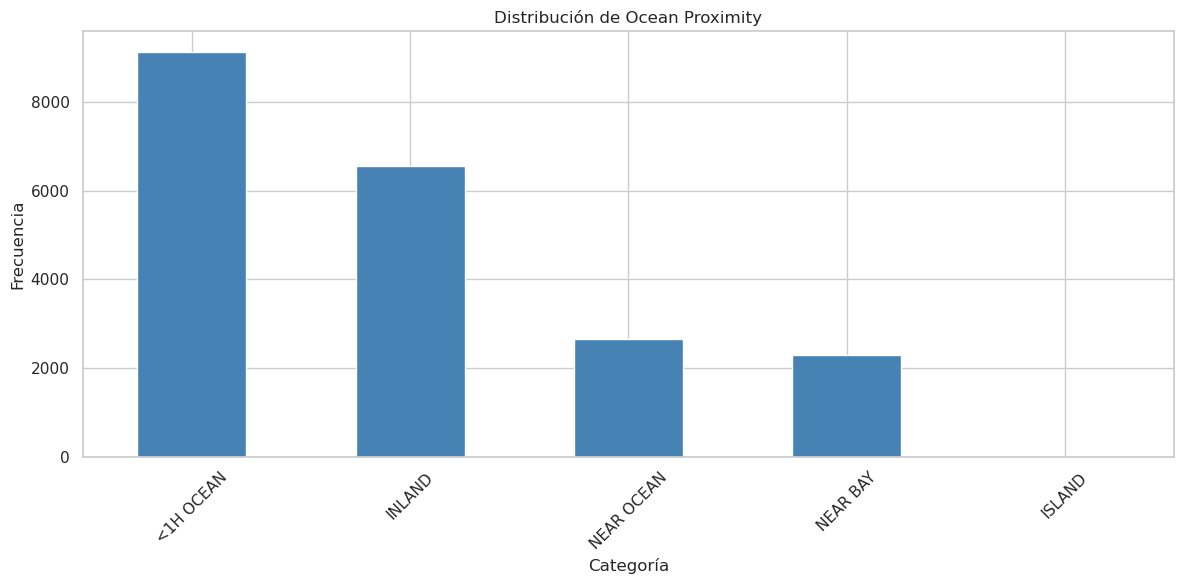

In [6]:
print(housing['ocean_proximity'].value_counts())
housing['ocean_proximity'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Distribución de Ocean Proximity')
plt.xlabel('Categoría')
plt.ylabel('Frecuencia')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Histogramas de Variables Numéricas

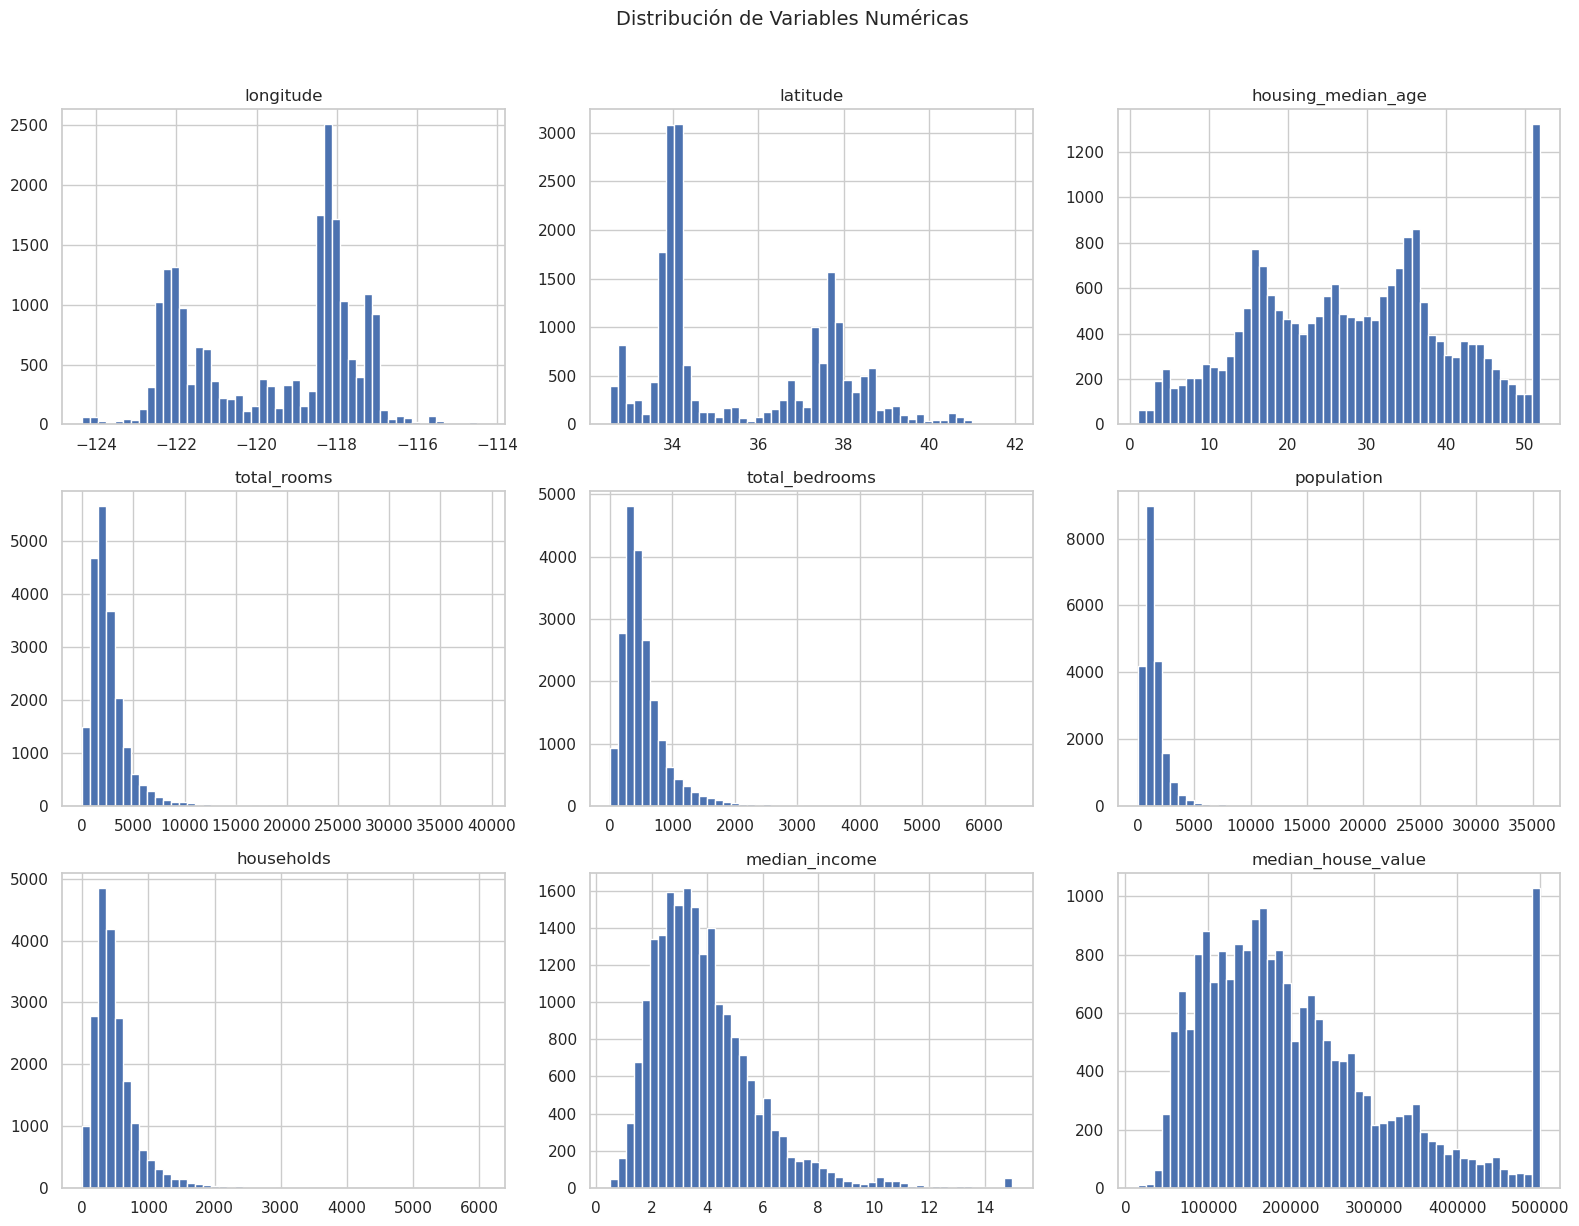

In [7]:
housing.hist(bins=50, figsize=(16, 12))
plt.suptitle('Distribución de Variables Numéricas', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Visualización Geoespacial

Usamos `longitude` y `latitude` como coordenadas. El color representa el precio medio de la vivienda y el tamaño del punto la densidad poblacional.

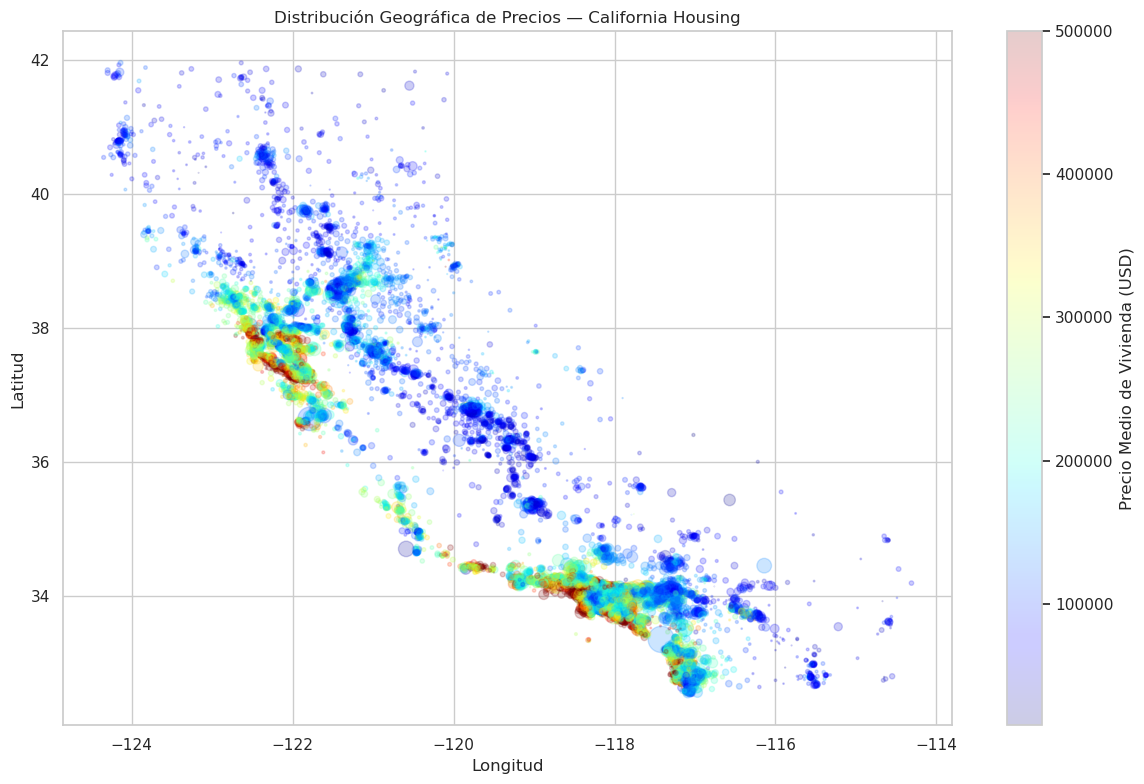

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    housing['longitude'],
    housing['latitude'],
    alpha=0.2,
    c=housing['median_house_value'],
    cmap='jet',
    s=housing['population'] / 100,
    label='Población'
)

plt.colorbar(scatter, ax=ax, label='Precio Medio de Vivienda (USD)')
ax.set_title('Distribución Geográfica de Precios — California Housing')
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
plt.tight_layout()
plt.show()

## 5. Análisis de Correlaciones

In [9]:
corr_matrix = housing.corr(numeric_only=True)
target_corr = corr_matrix['median_house_value'].sort_values(ascending=False)
print('Correlación con median_house_value:')
print(target_corr)

Correlación con median_house_value:
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64


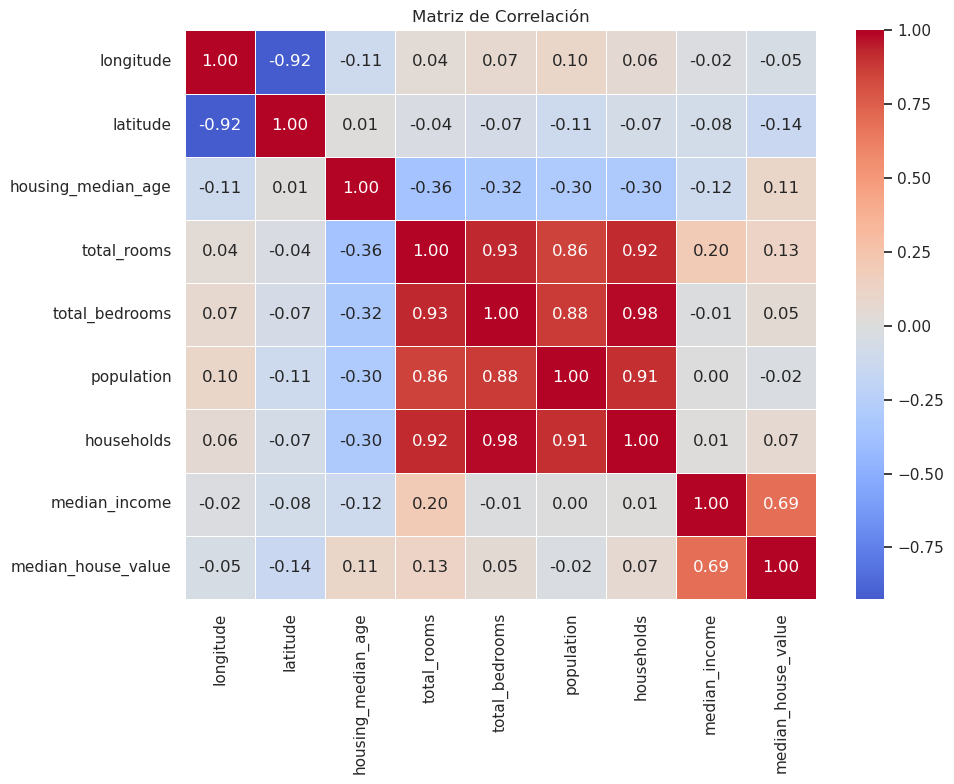

In [10]:
# Heatmap de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f',
    cmap='coolwarm', center=0,
    linewidths=0.5
)
plt.title('Matriz de Correlación')
plt.tight_layout()
plt.show()

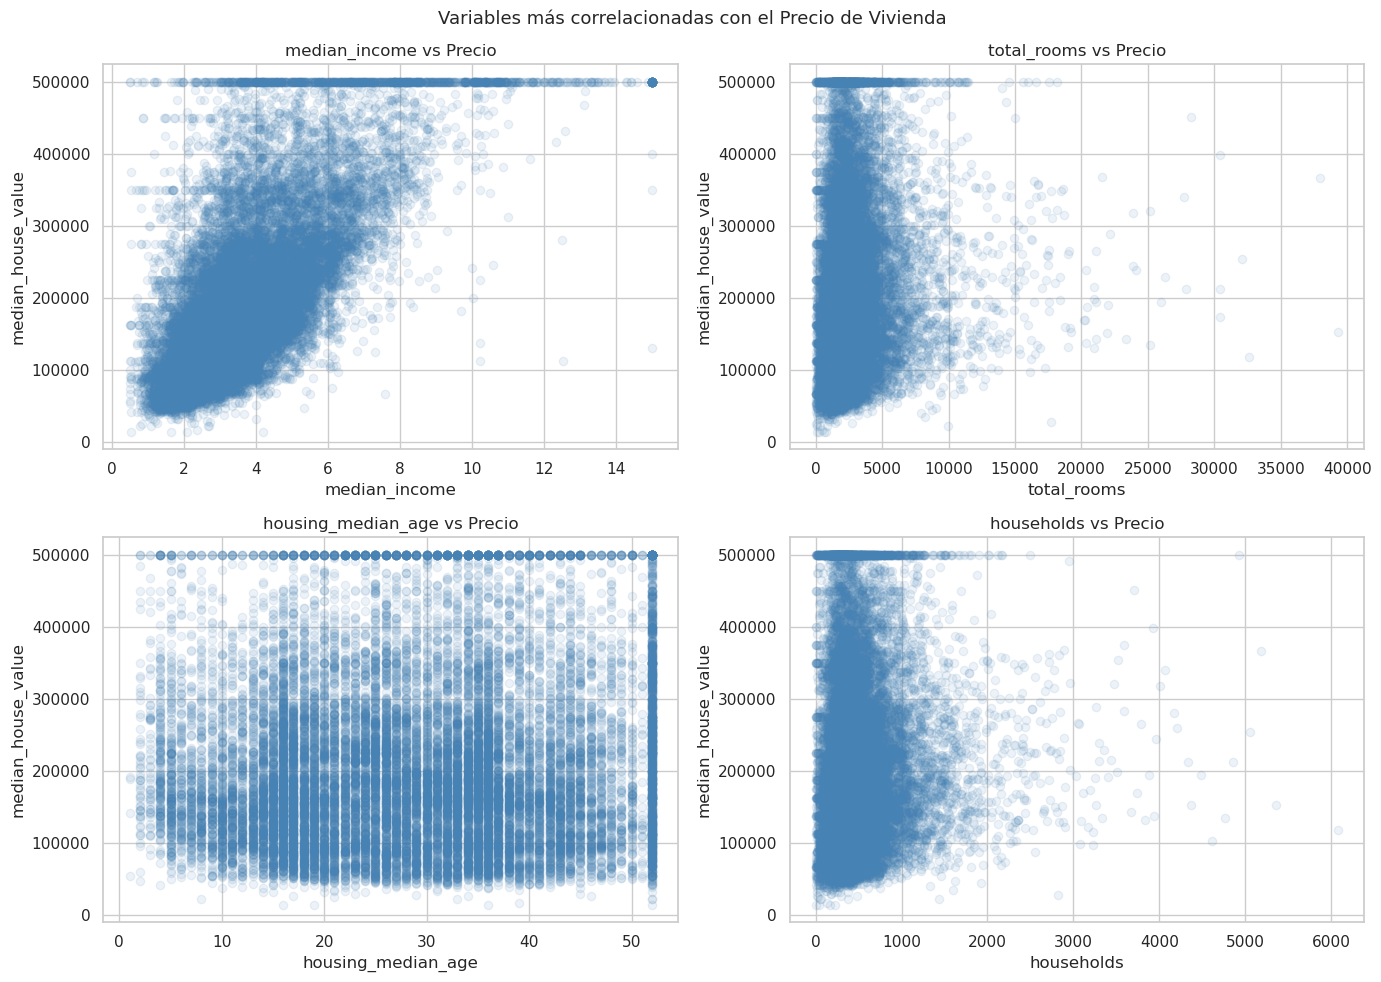

In [11]:
# Scatter plots de las variables más correlacionadas con el precio
top_features = ['median_income', 'total_rooms', 'housing_median_age', 'households']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top_features):
    axes[i].scatter(housing[feat], housing['median_house_value'], alpha=0.1, color='steelblue')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('median_house_value')
    axes[i].set_title(f'{feat} vs Precio')

plt.suptitle('Variables más correlacionadas con el Precio de Vivienda', fontsize=13)
plt.tight_layout()
plt.show()

## 6. Conclusiones del EDA

*(Completa esta sección con tus hallazgos en lenguaje de negocio)*

**Hallazgos principales:**

1. **Completitud:** La columna `total_bedrooms` tiene aproximadamente **~1.0%** de valores faltantes (207 de 20,640 registros). Se deberá imputar en la fase de limpieza.

2. **Distribuciones:** Variables como `median_house_value` y `median_income` muestran un techo artificial (valores truncados). Esto puede afectar el rendimiento de modelos lineales.

3. **Geografía:** Los precios más altos se concentran en la costa (Bay Area y Los Ángeles). La ubicación es un predictor relevante.

4. **Variable más prometedora:** `median_income` muestra la correlación más alta con el precio (~0.69), lo que tiene sentido desde el punto de vista de negocio: distritos con mayor ingreso tienden a tener viviendas más costosas.

5. **Variables ruidosas:** `total_rooms` y `households` por sí solas tienen poca correlación, pero combinadas (ej. `rooms_per_household`) podrían ser más informativas — esto se explorará en la Fase 2.